In [ ]:
import os
# os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import json
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
DATA_DIR = Path("dataset")
IMG_SIZE = 160
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()

VAL_RATIO = 0.15
TEST_RATIO = 0.15
TRAIN_RATIO = 1.0 - VAL_RATIO - TEST_RATIO

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10
FINE_TUNE_LAYERS = 40

MODEL_PATH = "attentive_model.pth"
TORCHSCRIPT_PATH = "attentive_model_scripted.pt"
LABELS_PATH = "labels.json"
SPLITS_PATH = "dataset_splits.json"
METRICS_PATH = "metrics_report.json"

class_names = ["not_attentive", "attentive"]

In [ ]:
def collect_filepaths_and_labels(data_dir, class_names):
    '''
    Scans the dataset directory structure to collect image file paths and their corresponding class labels.
    Also counts the number of samples per class for imbalance analysis.
    '''
    filepaths, labels = [], []
    per_class_counts = {}
    supported_ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

    for class_idx, class_name in enumerate(class_names):
        class_dir = data_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class directory: {class_dir}")

        class_files = []
        for ext in supported_ext:
            class_files.extend(class_dir.glob(ext))
        class_files = sorted(class_files)

        per_class_counts[class_name] = len(class_files)
        filepaths.extend([str(path) for path in class_files])
        labels.extend([class_idx] * len(class_files))

    if not filepaths:
        raise RuntimeError(f"No images found under {data_dir}")

    return filepaths, np.array(labels, dtype=np.int32), per_class_counts


def describe_split(name, labels):
    '''
    Prints the distribution of class labels in a given dataset split.
    '''
    labels = np.array(labels, dtype=np.int32)
    counts = np.bincount(labels, minlength=len(class_names))
    total = int(counts.sum())

    print(f"\n{name} split ({total} samples)")
    for idx, class_name in enumerate(class_names):
        pct = (counts[idx] / total) * 100 if total > 0 else 0.0
        print(f"  {class_name}: {counts[idx]} ({pct:.2f}%)")


all_paths, all_labels, dataset_counts = collect_filepaths_and_labels(DATA_DIR, class_names)

print("Dataset audit:")
for class_name in class_names:
    print(f"  {class_name}: {dataset_counts[class_name]}")

minority_count = max(1, min(dataset_counts.values()))
majority_count = max(dataset_counts.values())
imbalance_ratio = majority_count / minority_count
print(f"Class imbalance ratio: {imbalance_ratio:.2f}x")

train_paths, temp_paths, y_train, y_temp = train_test_split(
    all_paths,
    all_labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=all_labels,
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths,
    y_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=y_temp,
)

train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

describe_split("Train", y_train)
describe_split("Validation", y_val)
describe_split("Test", y_test)

split_payload = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "class_names": class_names,
    "train_files": train_paths,
    "val_files": val_paths,
    "test_files": test_paths,
}
with open(SPLITS_PATH, "w") as file:
    json.dump(split_payload, file, indent=2)
print(f"\nSaved split manifest: {SPLITS_PATH}")

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1], dtype=np.int32),
    y=np.array(y_train, dtype=np.int32),
)
class_weight_dict = {idx: float(weight) for idx, weight in enumerate(class_weight_values)}

neg_count = max(1, int(np.sum(np.array(y_train) == 0)))
pos_count = max(1, int(np.sum(np.array(y_train) == 1)))
pos_weight = neg_count / pos_count

print(f"\nClass weights: {class_weight_dict}")
print(f"BCE pos_weight: {pos_weight:.4f}")

Dataset audit:
  not_attentive: 5000
  attentive: 5000
Class imbalance ratio: 1.00x

Train split (7000 samples)
  not_attentive: 3500 (50.00%)
  attentive: 3500 (50.00%)

Validation split (1500 samples)
  not_attentive: 750 (50.00%)
  attentive: 750 (50.00%)

Test split (1500 samples)
  not_attentive: 750 (50.00%)
  attentive: 750 (50.00%)

Saved split manifest: dataset_splits.json

Class weights: {0: 1.0, 1: 1.0}
BCE pos_weight: 1.0000


In [ ]:
class ImagePathDataset(Dataset):
    '''
    A dataset for loading images from file paths and their corresponding labels.
    '''
    def __init__(self, paths, labels, transform=None):
        '''
        Initializes the dataset with image paths and labels.
        '''
        self.paths = list(paths)
        self.labels = np.array(labels, dtype=np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        '''
        Loads an image and its label, applies transformations, and returns them.
        '''
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImagePathDataset(train_paths, y_train, transform=train_transform)
val_dataset = ImagePathDataset(val_paths, y_val, transform=eval_transform)
test_dataset = ImagePathDataset(test_paths, y_test, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"DataLoader sizes - train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

DataLoader sizes - train: 7000, val: 1500, test: 1500


In [ ]:
class AttentiveMobileNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()

        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(in_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x


model = AttentiveMobileNetV2().to(device)

for parameter in model.backbone.features.parameters():
    parameter.requires_grad = False

trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Model initialized - trainable params: {trainable_params:,} / total params: {total_params:,}")

Model initialized - trainable params: 82,049 / total params: 2,305,921


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device))

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    '''
    Computes binary classification metrics given true labels and predicted probabilities.
    '''
    y_true = np.asarray(y_true, dtype=np.int32)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(np.int32)

    accuracy = float((y_pred == y_true).mean())
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))

    if len(np.unique(y_true)) > 1:
        auc = float(roc_auc_score(y_true, y_prob))
    else:
        auc = 0.5

    metrics = {
        "accuracy": accuracy,
        "auc": auc,
        "precision": precision,
        "recall": recall,
    }
    return metrics


def run_epoch(model, loader, criterion, optimizer=None):
    '''
    Runs one epoch of training or evaluation depending on whether an optimizer is provided.
    '''
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_probs, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY).view(-1, 1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        probs = torch.sigmoid(logits.detach()).cpu().numpy().ravel()
        all_probs.append(probs)
        all_labels.append(labels.detach().cpu().numpy().ravel())

    y_prob = np.concatenate(all_probs).astype(np.float32)
    y_true = np.concatenate(all_labels).astype(np.int32)

    metrics = compute_binary_metrics(y_true, y_prob)
    metrics["loss"] = float(total_loss / max(1, len(loader.dataset)))
    return metrics


def collect_predictions(model, loader):
    '''
     Collects predicted probabilities and true labels from the model for a given data loader.
    '''
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.append(probs)
            all_labels.append(labels.numpy().ravel())

    y_prob = np.concatenate(all_probs).astype(np.float32)
    y_true = np.concatenate(all_labels).astype(np.int32)
    return y_true, y_prob


def init_history():
    return {
        "loss": [], "accuracy": [], "auc": [], "precision": [], "recall": [],
        "val_loss": [], "val_accuracy": [], "val_auc": [], "val_precision": [], "val_recall": [],
    }


def append_history(history, train_metrics, val_metrics):
    '''
    Appends metrics from a training or validation epoch to the history dictionary.
    '''
    history["loss"].append(train_metrics["loss"])
    history["accuracy"].append(train_metrics["accuracy"])
    history["auc"].append(train_metrics["auc"])
    history["precision"].append(train_metrics["precision"])
    history["recall"].append(train_metrics["recall"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])


def train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, stage_name):
    '''
        Function to train the model
    '''
    history = init_history()
    best_val_accuracy = -np.inf
    best_state = None
    epochs_without_improvement = 0
    patience = 4

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_metrics["accuracy"])
        append_history(history, train_metrics, val_metrics)

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"[{stage_name}] Epoch {epoch:02d}/{epochs:02d} | "
            f"loss {train_metrics['loss']:.4f} | val_loss {val_metrics['loss']:.4f} | "
            f"acc {train_metrics['accuracy']:.4f} | val_acc {val_metrics['accuracy']:.4f} | lr {current_lr:.2e}"
        )

        if val_metrics["accuracy"] > best_val_accuracy + 1e-5:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[{stage_name}] Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return history, float(best_val_accuracy)

In [ ]:
# Stage 1 - Train only the head
optimizer_stage1 = torch.optim.Adam(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=1e-3,
)
scheduler_stage1 = ReduceLROnPlateau(
    optimizer_stage1,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

history1, best_val_acc_stage1 = train_stage(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    scheduler_stage1,
    epochs=INITIAL_EPOCHS,
    stage_name="Stage1",
)

# Stage 2 - Fine-tune last 40 backbone blocks
for parameter in model.backbone.features.parameters():
    parameter.requires_grad = False

num_blocks = len(model.backbone.features)
unfreeze_blocks = min(FINE_TUNE_LAYERS, num_blocks)

for block in list(model.backbone.features.children())[-unfreeze_blocks:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

for module in model.modules():
    if isinstance(module, nn.BatchNorm2d):
        module.eval()
        for parameter in module.parameters():
            parameter.requires_grad = False

optimizer_stage2 = torch.optim.Adam(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=1e-5,
)
scheduler_stage2 = ReduceLROnPlateau(
    optimizer_stage2,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

print(f"Fine-tuning last {unfreeze_blocks} backbone blocks out of {num_blocks}.")
history2, best_val_acc_stage2 = train_stage(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    scheduler_stage2,
    epochs=FINE_TUNE_EPOCHS,
    stage_name="Stage2",
)

print(f"Best validation accuracy - Stage1: {best_val_acc_stage1:.4f}")
print(f"Best validation accuracy - Stage2: {best_val_acc_stage2:.4f}")

[Stage1] Epoch 01/10 | loss 0.1910 | val_loss 0.0965 | acc 0.9337 | val_acc 0.9707 | lr 1.00e-03
[Stage1] Epoch 02/10 | loss 0.1264 | val_loss 0.0817 | acc 0.9591 | val_acc 0.9753 | lr 1.00e-03
[Stage1] Epoch 03/10 | loss 0.1136 | val_loss 0.0744 | acc 0.9633 | val_acc 0.9767 | lr 1.00e-03
[Stage1] Epoch 04/10 | loss 0.1042 | val_loss 0.0668 | acc 0.9657 | val_acc 0.9773 | lr 1.00e-03
[Stage1] Epoch 05/10 | loss 0.0966 | val_loss 0.0603 | acc 0.9673 | val_acc 0.9807 | lr 1.00e-03
[Stage1] Epoch 06/10 | loss 0.0881 | val_loss 0.0608 | acc 0.9700 | val_acc 0.9807 | lr 1.00e-03
[Stage1] Epoch 07/10 | loss 0.0837 | val_loss 0.0564 | acc 0.9736 | val_acc 0.9780 | lr 1.00e-03
[Stage1] Epoch 08/10 | loss 0.0882 | val_loss 0.0577 | acc 0.9704 | val_acc 0.9820 | lr 1.00e-03
[Stage1] Epoch 09/10 | loss 0.0840 | val_loss 0.0567 | acc 0.9731 | val_acc 0.9793 | lr 1.00e-03
[Stage1] Epoch 10/10 | loss 0.0846 | val_loss 0.0594 | acc 0.9717 | val_acc 0.9813 | lr 1.00e-03
Fine-tuning last 19 backbone b

In [12]:
model_state_cpu = {key: value.detach().cpu() for key, value in model.state_dict().items()}
checkpoint_payload = {
    "model_state_dict": model_state_cpu,
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "seed": SEED,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
}

torch.save(checkpoint_payload, MODEL_PATH)
print(f"Saved model checkpoint: {MODEL_PATH}")

with open(LABELS_PATH, "w") as file:
    json.dump({str(idx): name for idx, name in enumerate(class_names)}, file, indent=2)
print(f"Saved labels: {LABELS_PATH}")

model.to(device)

Saved model checkpoint: attentive_model.pth
Saved labels: labels.json


AttentiveMobileNetV2(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kern

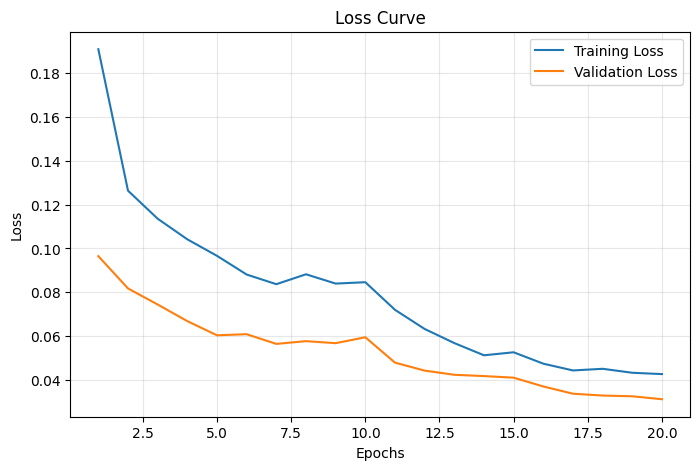

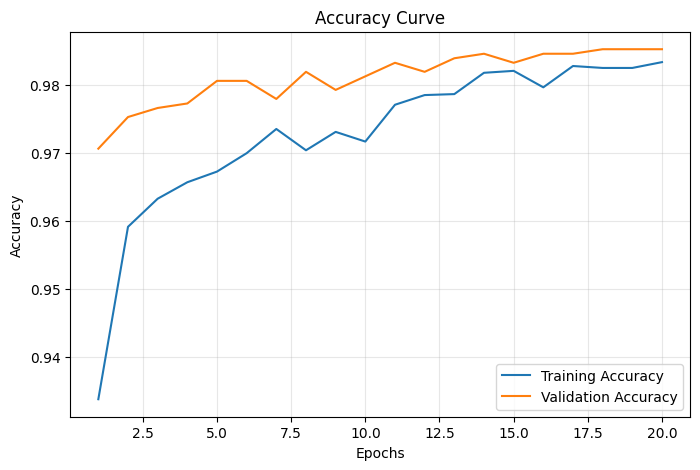

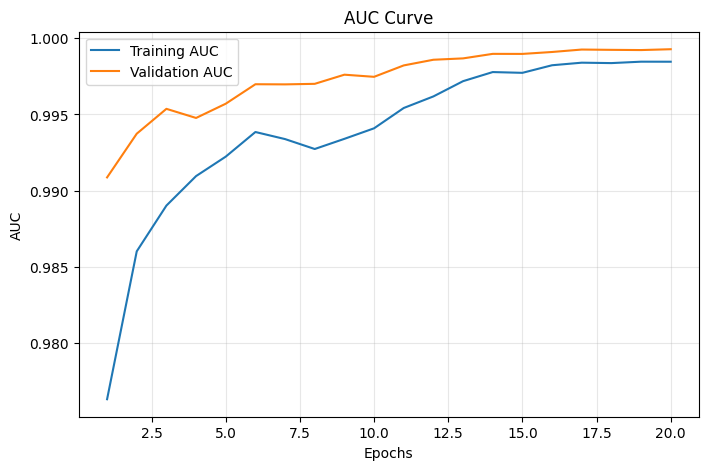

In [ ]:
def plot_training(history1, history2):
    def merge_metric(metric_name):
        return history1.get(metric_name, []) + history2.get(metric_name, [])

    metrics_to_plot = [
        ("loss", "val_loss", "Loss", "loss_plot.png"),
        ("accuracy", "val_accuracy", "Accuracy", "accuracy_plot.png"),
        ("auc", "val_auc", "AUC", "auc_plot.png"),
    ]

    total_epochs = len(merge_metric("loss"))
    epochs = range(1, total_epochs + 1)

    for train_key, val_key, title, output_name in metrics_to_plot:
        train_values = merge_metric(train_key)
        val_values = merge_metric(val_key)

        if not train_values or not val_values:
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, train_values, label=f"Training {title}")
        plt.plot(epochs, val_values, label=f"Validation {title}")
        plt.xlabel("Epochs")
        plt.ylabel(title)
        plt.title(f"{title} Curve")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(output_name, dpi=150, bbox_inches="tight")
        plt.show()


plot_training(history1, history2)


Test Results:
accuracy: 0.9827
auc: 0.9983
precision: 0.9665
recall: 1.0000
loss: 0.0439

Confusion Matrix (rows=true, cols=pred):
[[724  26]
 [  0 750]]
Sensitivity (attentive recall): 1.0000
Specificity (not_attentive recall): 0.9653
ROC-AUC: 0.9983
PR-AUC: 0.9983

Classification Report:
               precision    recall  f1-score   support

not_attentive     1.0000    0.9653    0.9824       750
    attentive     0.9665    1.0000    0.9830       750

     accuracy                         0.9827      1500
    macro avg     0.9832    0.9827    0.9827      1500
 weighted avg     0.9832    0.9827    0.9827      1500



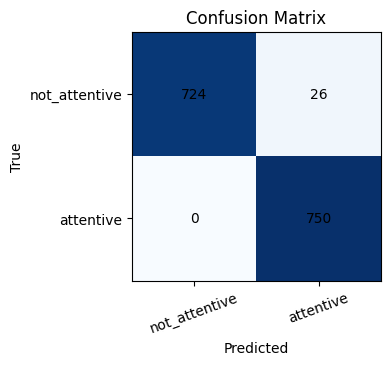


Saved metrics report: metrics_report.json


In [14]:
test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)
y_true, y_prob = collect_predictions(model, test_loader)
y_pred = (y_prob >= 0.5).astype(np.int32)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

sensitivity = float(tp / (tp + fn + 1e-8))
specificity = float(tn / (tn + fp + 1e-8))
roc_auc = float(roc_auc_score(y_true, y_prob))
pr_auc = float(average_precision_score(y_true, y_prob))

print("\nTest Results:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)
print(f"Sensitivity (attentive recall): {sensitivity:.4f}")
print(f"Specificity (not_attentive recall): {specificity:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], class_names, rotation=20)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

metrics_payload = {
    "seed": SEED,
    "threshold": 0.5,
    "class_names": class_names,
    "split_sizes": {
        "train": int(len(y_train)),
        "val": int(len(y_val)),
        "test": int(len(y_test)),
    },
    "class_weights": class_weight_dict,
    "pos_weight": float(pos_weight),
    "test_metrics": test_metrics,
    "confusion_matrix": cm.tolist(),
    "sensitivity": sensitivity,
    "specificity": specificity,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
}

with open(METRICS_PATH, "w") as file:
    json.dump(metrics_payload, file, indent=2)

print(f"\nSaved metrics report: {METRICS_PATH}")

In [15]:
model.eval()
model_cpu = model.to("cpu")

example_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
scripted_model = torch.jit.trace(model_cpu, example_input)
scripted_model.save(TORCHSCRIPT_PATH)
print(f"Saved TorchScript model: {TORCHSCRIPT_PATH}")

sample_images, _ = next(iter(test_loader))
sample_images = sample_images[: min(32, sample_images.size(0))]

with torch.no_grad():
    torch_probs = torch.sigmoid(model_cpu(sample_images)).numpy().ravel()
    scripted_probs = torch.sigmoid(scripted_model(sample_images)).numpy().ravel()

max_abs_diff = float(np.max(np.abs(torch_probs - scripted_probs)))
mean_abs_diff = float(np.mean(np.abs(torch_probs - scripted_probs)))

print(f"TorchScript parity - max abs diff: {max_abs_diff:.6f}")
print(f"TorchScript parity - mean abs diff: {mean_abs_diff:.6f}")

model.to(device)

Saved TorchScript model: attentive_model_scripted.pt
TorchScript parity - max abs diff: 0.000000
TorchScript parity - mean abs diff: 0.000000


AttentiveMobileNetV2(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kern